# Dataset

In [1]:
# dataset.py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class DrivingDataset(Dataset):
    def __init__(self, npz_path: str):
        super().__init__()
        D = np.load(npz_path)

        # ---- Controls: [B,200] = (100 vel + 100 steer) ----
        controls = D["controls"].astype(np.float32)
        self.controls = controls

        # ---- Ego (8) + Lane (2) -> Ego(10) ----
        ego = D["ego"].astype(np.float32)
        x, y, vx, vy, ax, ay, psi, psidot = [ego[:, i] for i in range(8)]

        lane = D["lane"].astype(np.float32)
        y_lb, y_ub = lane[:, 0], lane[:, 1]

        ego_feats = np.stack(
            [x, y, vx, vy, ax, ay, psi, psidot, y_lb, y_ub], axis=1
        ).astype(np.float32)

        # ---- Obstacles: obs [B,56] -> [B,7,8] -> PN features [B,8,8] ----
        obs_flat = D["obs"].astype(np.float32)
        B = obs_flat.shape[0]
        N_obs, FEATS_PER_OBS = 8, 7

        obs_blocks = obs_flat.reshape(B, FEATS_PER_OBS, N_obs)
        x_o, y_o, vx_o, vy_o, psi_o, dimx_o, dimy_o = [obs_blocks[:, i, :] for i in range(7)]

        relx   = x_o - x[:, None]
        rely   = y_o - y[:, None]
        cospsi = np.cos(psi_o)
        sinpsi = np.sin(psi_o)

        obs_feats = np.stack(
            [relx, rely, vx_o, vy_o, cospsi, sinpsi, dimx_o, dimy_o], axis=2
        ).astype(np.float32)  

        # ---- Normalization (dataset-wide) ----
        self.B     = B
        self.N_obs = N_obs

        self.ego_mean = ego_feats.mean(axis=0)
        self.ego_std  = ego_feats.std(axis=0) + 1e-6

        obs_flat_8 = obs_feats.reshape(self.B * self.N_obs, -1)
        self.obs_mean = obs_flat_8.mean(axis=0)
        self.obs_std  = obs_flat_8.std(axis=0) + 1e-6

        self.ego_feats = ego_feats
        self.obs_feats = obs_feats

    def __len__(self):
        return self.B

    def __getitem__(self, i: int):
        # Normalize ego & obstacles
        ego = (self.ego_feats[i] - self.ego_mean) / self.ego_std          
        obs = (self.obs_feats[i] - self.obs_mean) / self.obs_std          

        # Controls: first 100 velocity, next 100 steering
        vel   = self.controls[i, :100]
        steer = self.controls[i, 100:200]
        y = np.stack([vel, steer], axis=0).astype(np.float32)              

        return torch.from_numpy(ego), torch.from_numpy(obs), torch.from_numpy(y)

def make_loader(npz_path, batch_size=128, shuffle=True, num_workers=4, pin_memory=True):
    ds = DrivingDataset(npz_path)
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
        drop_last=False
    )
    return ds, dl


# Training

In [2]:

import os, time, math, torch
from torch.utils.data import DataLoader, random_split
from model_6 import PolicySeqFlow


# ---- Config ----
DATA_FILE   = "./data_train.npz"
SAVE_DIR    = "./checkpoints"
BATCH_SIZE  = 256
VAL_SPLIT   = 0.10
LR          = 1e-4
EPOCHS      = 300
CLIP        = 5.0
SEED        = 42  # for dataset split
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(SAVE_DIR, exist_ok=True)
torch.manual_seed(SEED)

# ---- Split dataset + loaders  ----
ds_full = DrivingDataset(DATA_FILE)
H       = ds_full.controls.shape[1] // 2  # 200 -> H=100

n_total = len(ds_full)
n_val   = max(1, int(VAL_SPLIT * n_total))
n_train = n_total - n_val
tr_ds, va_ds = random_split(ds_full, [n_train, n_val],
                            generator=torch.Generator().manual_seed(SEED))

train_dl = DataLoader(
    tr_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True,
    persistent_workers=True, drop_last=False
)
val_dl = DataLoader(
    va_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True,
    persistent_workers=True, drop_last=False
)

# ---- Model ----
model = PolicySeqFlow(ctx_dim=128, horizon=H, hidden=256).to(DEVICE)

# ----- Loss function -----
def _fm_batch_prep(y, device):
    """y:[B,2,H] -> (t:[B,1], x_t:[B,2H], dx_t:[B,2H])"""
    B, _, H = y.shape
    x1 = y.permute(0, 2, 1).reshape(B, 2*H)      # [B,2H] ---- GD
    x0 = torch.randn_like(x1)                     # [B,2H]-----Noise
    t  = torch.rand(B, 1, device=device)         # [B,1]------Random t
    x_t  = (1.0 - t) * x0 + t * x1               # [B,2H]
    dx_t = (x1 - x0)                              # [B,2H]---- loss
    return t, x_t, dx_t, H

def train_epoch_fb(model, optimizer, train_dl, device, clip=5.0):
    model.train()
    total = 0.0
    for ego, obs, y in train_dl:
        ego = ego.to(device, non_blocking=True)   # [B,10]------Ego
        obs = obs.to(device, non_blocking=True)   # [B,8,8]----Obs
        y   = y.to(device, non_blocking=True)     # [B,2,H]------Controls

        t, x_t, dx_t, H_ = _fm_batch_prep(y, device) # loss
        

        ctx  = model.context(ego, obs)            # [B,C]-----Obs+Ego -> Context
        pred = model.fm(t, x_t, ctx)              # [B,2H]-----Flow model pred

        loss = torch.mean((pred - dx_t)**2)       

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        total += loss.item()
    return total / max(1, len(train_dl))

@torch.no_grad()
def eval_epoch_fb(model, val_dl, device):
    model.eval()
    total = 0.0
    for ego, obs, y in val_dl:
        ego = ego.to(device, non_blocking=True)
        obs = obs.to(device, non_blocking=True)
        y   = y.to(device, non_blocking=True)

        t, x_t, dx_t, H_ = _fm_batch_prep(y, device)

        ctx  = model.context(ego, obs)
        pred = model.fm(t, x_t, ctx)

        loss = torch.mean((pred - dx_t)**2)       # FB val loss
        total += loss.item()
    return total / max(1, len(val_dl))

def train_like_fb(model,
                  train_dl,
                  val_dl,
                  epochs=EPOCHS,
                  lr=LR,
                  device=DEVICE,
                  clip=CLIP,
                  ckpt_best_path=os.path.join(SAVE_DIR, "fb_best_last.pt"),
                  ckpt_last_path=os.path.join(SAVE_DIR, "fb_last_last.pt"),
                  warmup_epochs=10):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    # 1) linear warmup 0 -> 1 over warmup_epochs
    warmup = torch.optim.lr_scheduler.LambdaLR(
        opt, lr_lambda=lambda e: (e + 1) / max(1, warmup_epochs)
    )
    # 2) cosine from epoch warmup_epochs+1 to epochs
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=max(1, epochs - warmup_epochs), eta_min=lr * 0.1
    )
    # chain schedulers
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        opt, schedulers=[warmup, cosine], milestones=[warmup_epochs]
    )

    best_val = math.inf
    for ep in range(1, epochs+1):
        t0 = time.time()
        tr = train_epoch_fb(model, opt, train_dl, device, clip=clip)
        va = eval_epoch_fb(model, val_dl, device)

        scheduler.step()  # step once per epoch

        cur_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {ep:03d} | lr {cur_lr:.2e} | train {tr:.6f} | val {va:.6f} | {time.time()-t0:.1f}s")

        if va < best_val:
            best_val = va
            torch.save(model.state_dict(), ckpt_best_path)
        torch.save(model.state_dict(), ckpt_last_path)

    return model



# ---- Model ----
model = PolicySeqFlow(ctx_dim=128, horizon=H, hidden=256).to(DEVICE)

model = train_like_fb(model, train_dl, val_dl, epochs=500)



Epoch 001 | lr 2.00e-05 | train 2.561137 | val 1.322215 | 10.7s
Epoch 002 | lr 3.00e-05 | train 1.241223 | val 1.191525 | 9.7s
Epoch 003 | lr 4.00e-05 | train 1.165724 | val 1.123224 | 9.7s
Epoch 004 | lr 5.00e-05 | train 1.100971 | val 1.064241 | 9.8s
Epoch 005 | lr 6.00e-05 | train 1.045185 | val 1.012416 | 9.7s
Epoch 006 | lr 7.00e-05 | train 0.989832 | val 0.954595 | 9.8s
Epoch 007 | lr 8.00e-05 | train 0.941313 | val 0.914000 | 10.2s
Epoch 008 | lr 9.00e-05 | train 0.894290 | val 0.868074 | 10.3s
Epoch 009 | lr 1.00e-04 | train 0.848782 | val 0.820454 | 9.8s


/home/ims_simon/miniconda3/envs/mir/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 010 | lr 1.00e-04 | train 0.803476 | val 0.796907 | 9.8s
Epoch 011 | lr 1.00e-04 | train 0.759374 | val 0.751619 | 10.1s
Epoch 012 | lr 1.00e-04 | train 0.721917 | val 0.701808 | 10.0s
Epoch 013 | lr 1.00e-04 | train 0.693222 | val 0.676598 | 9.8s
Epoch 014 | lr 1.00e-04 | train 0.664971 | val 0.648341 | 9.9s
Epoch 015 | lr 1.00e-04 | train 0.641642 | val 0.628679 | 9.9s
Epoch 016 | lr 1.00e-04 | train 0.620174 | val 0.603890 | 9.8s
Epoch 017 | lr 1.00e-04 | train 0.601440 | val 0.594968 | 9.8s
Epoch 018 | lr 9.99e-05 | train 0.583612 | val 0.571857 | 9.7s
Epoch 019 | lr 9.99e-05 | train 0.567026 | val 0.559653 | 9.7s
Epoch 020 | lr 9.99e-05 | train 0.551474 | val 0.540414 | 9.8s
Epoch 021 | lr 9.99e-05 | train 0.535060 | val 0.529898 | 9.7s
Epoch 022 | lr 9.99e-05 | train 0.520922 | val 0.512995 | 9.8s
Epoch 023 | lr 9.98e-05 | train 0.506381 | val 0.506031 | 10.0s
Epoch 024 | lr 9.98e-05 | train 0.494646 | val 0.491228 | 9.8s
Epoch 025 | lr 9.98e-05 | train 0.483241 | val 0.477

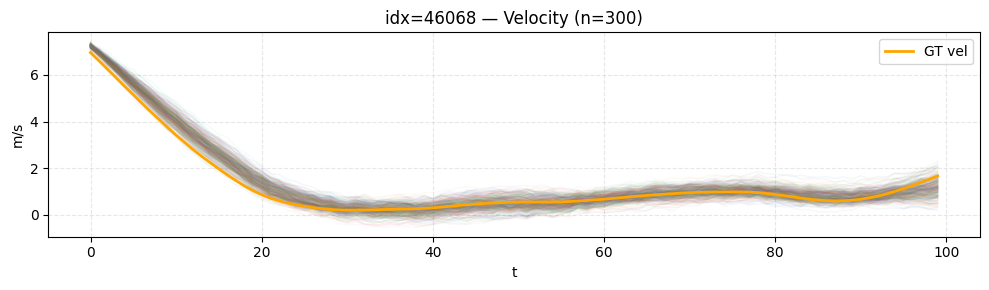

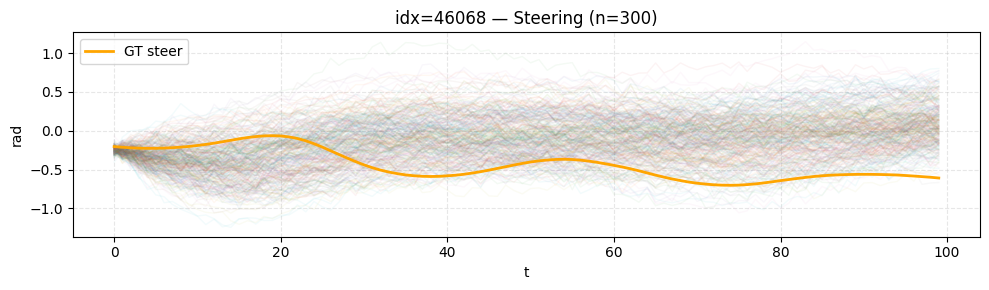

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import random

@torch.no_grad()
def sample_sequences(model, ego, obs, n_samples=300, n_int=10, sigma=0.8,
                     clamp_quantiles=None):
    """
    Returns: [n_samples, B, 2, H]
    Works with FMSeq (trajectory head): x ∈ R^{2H}, not per-timestep.
    """
    device = next(model.parameters()).device
    model.eval()

    ego, obs = ego.to(device), obs.to(device)     # From dataset
    ctx = model.context(ego, obs)                 # [B, C]
    B = ctx.size(0); H = getattr(model, "horizon", 100) # gives H=100 from model

    ts = torch.linspace(0.0, 1.0, n_int + 1, device=device) # Time steps

    if clamp_quantiles is not None:              # optional vel/steer clamp
        v_lo, v_hi, s_lo, s_hi = clamp_quantiles

    samples = []
    for _ in range(n_samples):
        # start from noise in trajectory space
        x = torch.randn(B, 2 * H, device=device) * sigma  # [B,2H]

        for i in range(n_int):
            t0, t1 = ts[i], ts[i+1]
            x = model.fm.step(x, t0, t1, ctx)             # Heun midpoint inside

            if clamp_quantiles is not None: # optional vel/steer clamp
                xv = x.view(B, H, 2)                      # [B,H,2] -> clamp per channel
                xv[..., 0] = xv[..., 0].clamp(v_lo, v_hi) # optional velocity clamp
                xv[..., 1] = xv[..., 1].clamp(s_lo, s_hi) # optional steering clamp
                x = xv.view(B, 2 * H)

        x_seq = x.view(B, H, 2).permute(0, 2, 1).contiguous()  # [B,2,H]
        samples.append(x_seq)

    return torch.stack(samples, dim=0)  # [n_samples, B, 2, H]


@torch.no_grad()
def plot_300_predictions_no_mean(model, ds, idx=0, n_samples=300, n_int=10, sigma=1.5,
                                 clamp_quantiles=None):
    """
    Draw 300 sampled sequences (thin) + GT (bold), no mean curve.
    """
    ego, obs, y = ds[idx]                         
    H = y.shape[-1] # Number of timesteps
    device = next(model.parameters()).device # gives weights and bias

    ego = ego.unsqueeze(0).to(device)  # add batch dimension
    obs = obs.unsqueeze(0).to(device)  # add batch dimension
    y_np = y.numpy()
    t = np.arange(H) # arrange of timesteps

    # Sample from FMSeq trajectory head
    S = sample_sequences(model, ego, obs, n_samples=n_samples, n_int=n_int,
                         sigma=sigma, clamp_quantiles=clamp_quantiles)  
    S = S[:, 0].cpu().numpy()                     

    # --- Velocity ---
    plt.figure(figsize=(10, 3))
    for k in range(n_samples):
        plt.plot(t, S[k, 0], alpha=0.05, linewidth=1)
    plt.plot(t, y_np[0], label="GT vel", linewidth=2, color="orange")
    plt.title(f"idx={idx} — Velocity (n={n_samples})")
    plt.xlabel("t"); plt.ylabel("m/s"); plt.grid(True, ls="--", alpha=0.3)
    plt.legend(); plt.tight_layout(); plt.show()

    # --- Steering ---
    plt.figure(figsize=(10, 3))
    for k in range(n_samples):
        plt.plot(t, S[k, 1], alpha=0.05, linewidth=1)
    plt.plot(t, y_np[1], label="GT steer", linewidth=2, color="orange")
    plt.title(f"idx={idx} — Steering (n={n_samples})")
    plt.xlabel("t"); plt.ylabel("rad"); plt.grid(True, ls="--", alpha=0.3)
    plt.legend(); plt.tight_layout(); plt.show()

ds = DrivingDataset("./data_train.npz")
plot_300_predictions_no_mean(model, ds, idx=random.randint(0, len(ds)-1), n_samples=300, n_int=10, sigma=1)
